**Importing Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Display charts properly
%matplotlib inline

**Importing Data**

In [6]:
df = pd.read_csv("Sales_Analysis_data.csv")
df.head(4)

,Order_ID,Order_Date,Ship_Date,Region,State,Category,Sub_Category,Customer_Name,Segment,Sales,Quantity,Discount,Profit
0,1000,01-01-2023 00:00,03-01-2023 00:00,Central,Tamil Nadu,Technology,Phones,Kiran,Consumer,7952.11,3,0.03,701.46
1,1001,02-01-2023 00:00,04-01-2023 00:00,South,Karnataka,Office Supplies,Binders,Asha,Consumer,8552.47,2,0.24,2482.17
2,1002,03-01-2023 00:00,05-01-2023 00:00,East,Tamil Nadu,Furniture,Chairs,Kiran,Home Office,2495.57,7,0.08,1457.26
3,1003,04-01-2023 00:00,06-01-2023 00:00,Central,Tamil Nadu,Technology,Phones,Arun,Consumer,9610.21,7,0.04,1301.60


In [7]:
df.shape

(800, 13)

In [8]:
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Region', 'State', 'Category',
       'Sub_Category', 'Customer_Name', 'Segment', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

**Data Understanding and Cleaning**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       800 non-null    int64  
 1   Order_Date     800 non-null    object 
 2   Ship_Date      800 non-null    object 
 3   Region         800 non-null    object 
 4   State          800 non-null    object 
 5   Category       800 non-null    object 
 6   Sub_Category   800 non-null    object 
 7   Customer_Name  800 non-null    object 
 8   Segment        800 non-null    object 
 9   Sales          800 non-null    float64
 10  Quantity       800 non-null    int64  
 11  Discount       800 non-null    float64
 12  Profit         800 non-null    float64
dtypes: float64(3), int64(2), object(8)
memory usage: 81.4+ KB


In [10]:
df.describe()

,Order_ID,Sales,Quantity,Discount,Profit
count,800.0000,800.000000,800.00000,800.000000,800.000000
mean,1399.5000,5099.360738,5.02875,0.147175,1254.524050
std,231.0844,2851.637551,2.52951,0.085993,1012.357828
min,1000.0000,100.120000,1.00000,0.000000,-478.360000
25%,1199.7500,2584.642500,3.00000,0.070000,396.255000
50%,1399.5000,5192.500000,5.00000,0.150000,1220.290000
75%,1599.2500,7527.160000,7.00000,0.220000,2096.490000
max,1799.0000,9989.040000,9.00000,0.300000,2997.730000


In [11]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Ship_Date        0
Region           0
State            0
Category         0
Sub_Category     0
Customer_Name    0
Segment          0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
print(df.duplicated().sum())

0


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(800, 13)

*Changing Datatype*

In [15]:
df['Order_Date']=pd.to_datetime(df['Order_Date'],format='mixed')

In [16]:
df['Ship_Date']=pd.to_datetime(df['Ship_Date'],format='mixed')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       800 non-null    int64         
 1   Order_Date     800 non-null    datetime64[ns]
 2   Ship_Date      800 non-null    datetime64[ns]
 3   Region         800 non-null    object        
 4   State          800 non-null    object        
 5   Category       800 non-null    object        
 6   Sub_Category   800 non-null    object        
 7   Customer_Name  800 non-null    object        
 8   Segment        800 non-null    object        
 9   Sales          800 non-null    float64       
 10  Quantity       800 non-null    int64         
 11  Discount       800 non-null    float64       
 12  Profit         800 non-null    float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(6)
memory usage: 81.4+ KB


**Fiscal year**

In [18]:
df['Fiscal_Year']=(df['Order_Date']+pd.DateOffset(months=9)).dt.year

**Fiscal Quarter**

In [19]:
df['Fiscal_Quarter']=('Q'+(df['Order_Date']+pd.DateOffset(months=9)).dt.quarter.astype(str))

In [20]:
df[['Order_Date','Fiscal_Year','Fiscal_Quarter']].head(10)

,Order_Date,Fiscal_Year,Fiscal_Quarter
0,2023-01-01,2023,Q4
1,2023-02-01,2023,Q4
2,2023-03-01,2023,Q4
3,2023-04-01,2024,Q1
4,2023-05-01,2024,Q1
5,2023-06-01,2024,Q1
6,2023-07-01,2024,Q2
7,2023-08-01,2024,Q2
8,2023-09-01,2024,Q2
9,2023-10-01,2024,Q3


In [21]:
df['Fiscal_Year'].value_counts()

Fiscal_Year
2024    366
2025    319
2023     90
2026     25
Name: count, dtype: int64

In [22]:
df['Fiscal_Quarter'].value_counts()

Fiscal_Quarter
Q4    225
Q2    193
Q1    191
Q3    191
Name: count, dtype: int64

**KPI Analysis**

*Total sales*

In [23]:
total_sales = round(df['Sales'].sum(),2)
print("Total sales:",total_sales)

Total sales: 4079488.59


*Total profit*

In [24]:
total_profit = round(df['Profit'].sum(),2)
print("Total profit:",total_profit)

Total profit: 1003619.24


*Total orders*

In [25]:
total_orders = df['Order_ID'].nunique()
print("Total orders:",total_orders)

Total orders: 800


*Average Order Value*

In [26]:
Avg_order_value=round(df['Sales'].sum()/df['Order_ID'].nunique(),2)
print("Average Order Value:",Avg_order_value)

Average Order Value: 5099.36


**Sales and Profit KPI Summary**

In [27]:
print("Sales and Profit KPIs")
print("-"*30)

print("Total sales:",round(df['Sales'].sum(),2))
print("Total profit:",round(df['Profit'].sum(),2))
print("Total orders:",df['Order_ID'].nunique())
print("Average Order Value:",round(df['Sales'].sum()/df['Order_ID'].nunique(),2))


Sales and Profit KPIs
------------------------------
Total sales: 4079488.59
Total profit: 1003619.24
Total orders: 800
Average Order Value: 5099.36


**Region-wise Sales Analysis**

In [28]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central     930145.14
East        980607.95
South      1215349.22
West        953386.28
Name: Sales, dtype: float64


*Bar Chart*

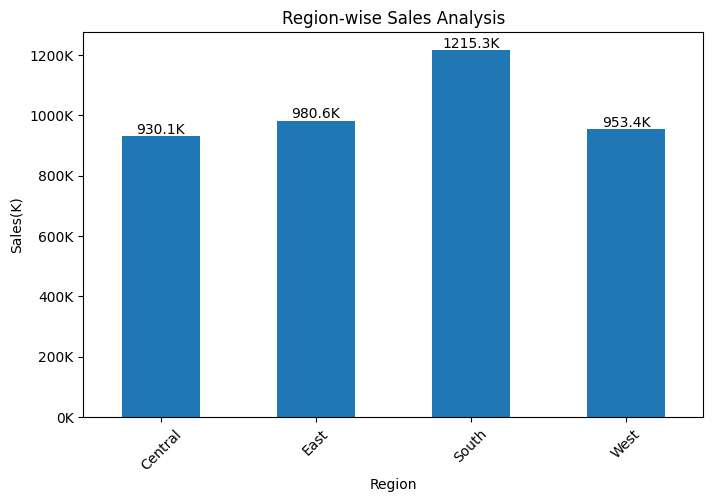

In [33]:
import matplotlib.ticker as ticker
plt.figure(figsize=(8,5))

ax = region_sales.plot(kind='bar')

plt.title('Region-wise Sales Analysis')
plt.xlabel('Region')
plt.ylabel('Sales(K)')

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

for i,value in enumerate(region_sales):
    ax.text(i,value,f'{value/1000:.1f}K',
            ha='center',va='bottom')
plt.xticks(rotation=45)
plt.show()

**Category-Wise sales Analysis**

In [35]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=True)
category_sales

Category
Furniture          1339200.90
Technology         1360252.07
Office Supplies    1380035.62
Name: Sales, dtype: float64

*Bar chart*

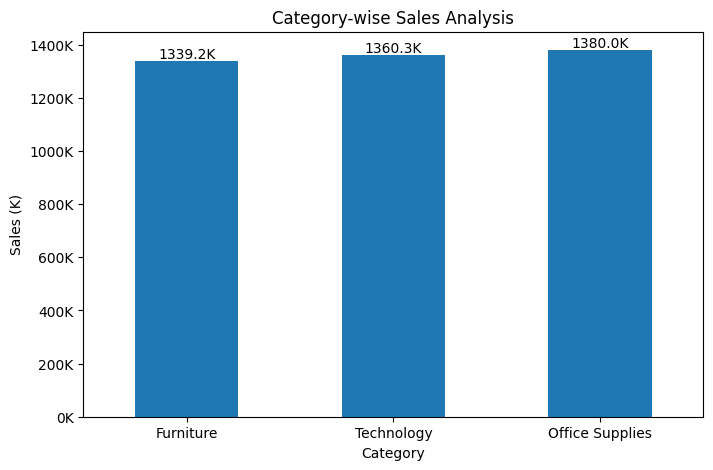

In [36]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = category_sales.plot(kind='bar')

plt.title('Category-wise Sales Analysis')
plt.xlabel('Category')
plt.ylabel('Sales (K)')

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

for i, value in enumerate(category_sales):
    ax.text(i, value,
            f'{value/1000:.1f}K',
            ha='center',
            va='bottom')

plt.xticks(rotation=0)
plt.show()

**Category-wise Profit Analysis**

In [38]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
category_profit

Category
Office Supplies    350864.31
Furniture          330106.93
Technology         322648.00
Name: Profit, dtype: float64

*Bar Chart*

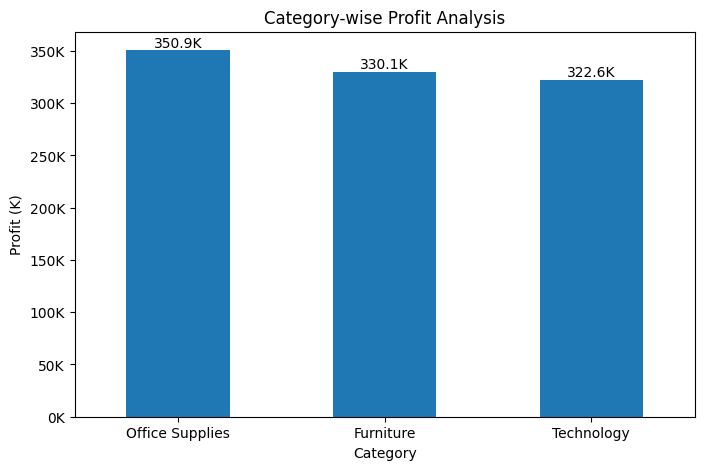

In [39]:
plt.figure(figsize=(8,5))

ax = category_profit.plot(kind='bar')

plt.title('Category-wise Profit Analysis')
plt.xlabel('Category')
plt.ylabel('Profit (K)')

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

for i, value in enumerate(category_profit):
    ax.text(i, value,
            f'{value/1000:.1f}K',
            ha='center',
            va='bottom')

plt.xticks(rotation=0)
plt.show()

**Top Customers Analysis**

In [41]:
top_customers = df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False)
top_customers

Customer_Name
Meena    770780.11
Kiran    686140.81
Arun     685690.67
Divya    680786.86
Asha     664649.60
Ravi     591440.54
Name: Sales, dtype: float64

*Bar Chart*

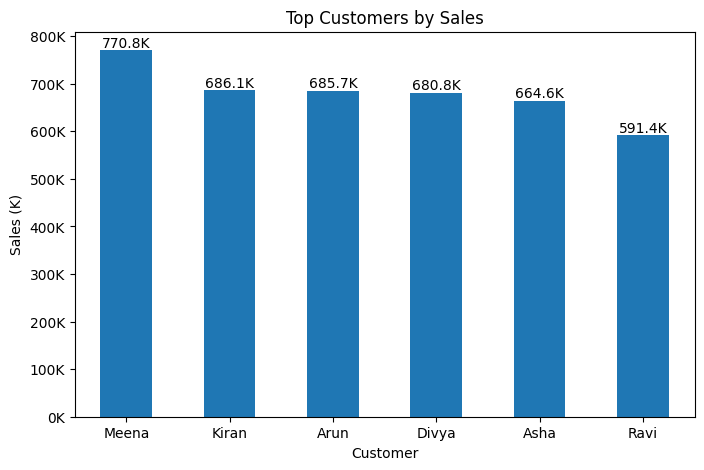

In [53]:
plt.figure(figsize=(8,5))

ax = top_customers.plot(kind='bar')

plt.title('Top Customers by Sales')
plt.xlabel('Customer')
plt.ylabel('Sales (K)')

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

for i, value in enumerate(top_customers):
    ax.text(i, value,
            f'{value/1000:.1f}K',
            ha='center',
            va='bottom')

plt.xticks(rotation=0)
plt.show()

**Monthly Sales Trend Analysis**

In [43]:
df['Month']=df['Order_Date'].dt.to_period('M')

In [49]:
monthly_sales=df.groupby('Month')['Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales

Month
2023-01    186407.29
2023-02    140636.01
2023-03    144689.41
2023-04    158447.82
2023-05    171382.08
2023-06    159479.08
2023-07    176317.17
2023-08    120594.82
2023-09    151878.41
2023-10    169670.74
2023-11    133376.21
2023-12    180118.38
2024-01    154598.91
2024-02    168849.49
2024-03    118139.15
2024-04    137651.75
2024-05    159685.91
2024-06    162316.67
2024-07    147840.71
2024-08    139043.61
2024-09    141531.18
2024-10    176335.76
2024-11    192832.77
2024-12    166425.18
2025-01    110341.44
2025-02    103875.33
2025-03      9616.98
2025-04      9043.52
2025-05     11425.98
2025-06     17686.77
2025-07      8804.92
2025-08     15476.57
2025-09     16261.79
2025-10      6303.96
2025-11      8035.75
2025-12      4367.07
Name: Sales, dtype: float64

*Line Chart*

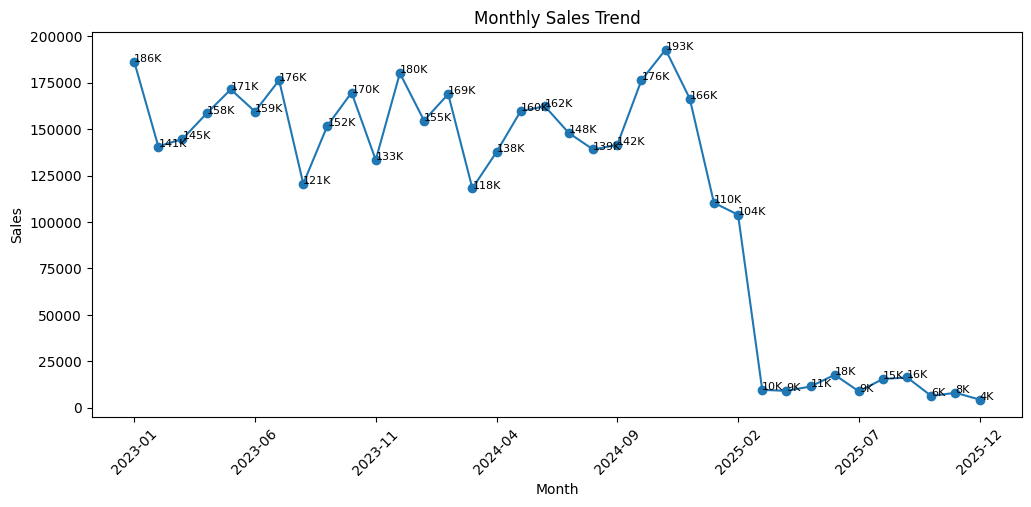

In [50]:
plt.figure(figsize=(12,5))

ax = monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

for i, value in enumerate(monthly_sales):
    ax.text(i, value,
            f'{value/1000:.0f}K',
            fontsize=8)

plt.xticks(rotation=45)
plt.show()

**Profit by Region**

In [54]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_profit

Region
South      266071.03
East       260783.81
West       246322.02
Central    230442.38
Name: Profit, dtype: float64

*Bar Chart*

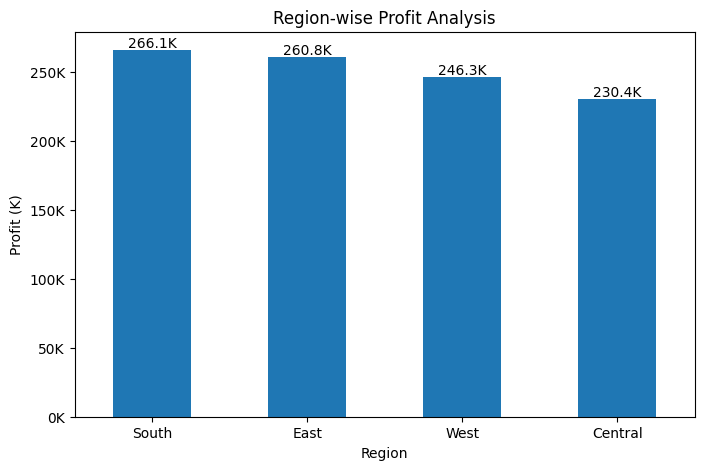

In [55]:
plt.figure(figsize=(8,5))

ax = region_profit.plot(kind='bar')

plt.title('Region-wise Profit Analysis')
plt.xlabel('Region')
plt.ylabel('Profit (K)')

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

for i, value in enumerate(region_profit):
    ax.text(i, value,
            f'{value/1000:.1f}K',
            ha='center',
            va='bottom')

plt.xticks(rotation=0)
plt.show()

**Discount vs Profit Analysis**

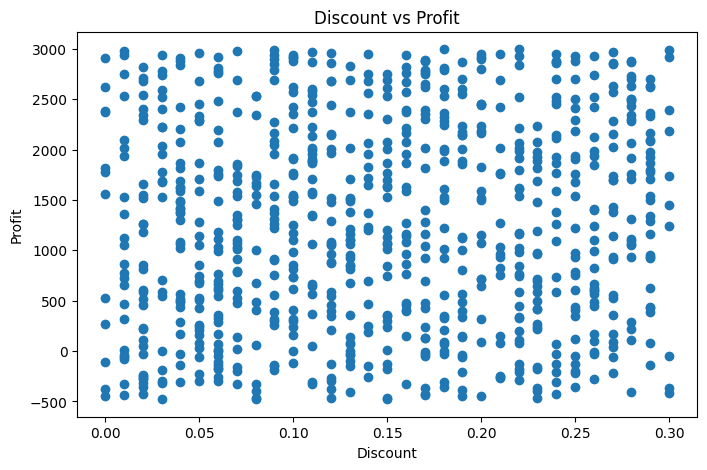

In [56]:
plt.figure(figsize=(8,5))

plt.scatter(df['Discount'], df['Profit'])

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

**Segment-wise Sales Analysis**

In [57]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=True)
segment_sales

Segment
Corporate      1226539.39
Home Office    1260920.25
Consumer       1592028.95
Name: Sales, dtype: float64

*Bar chart*

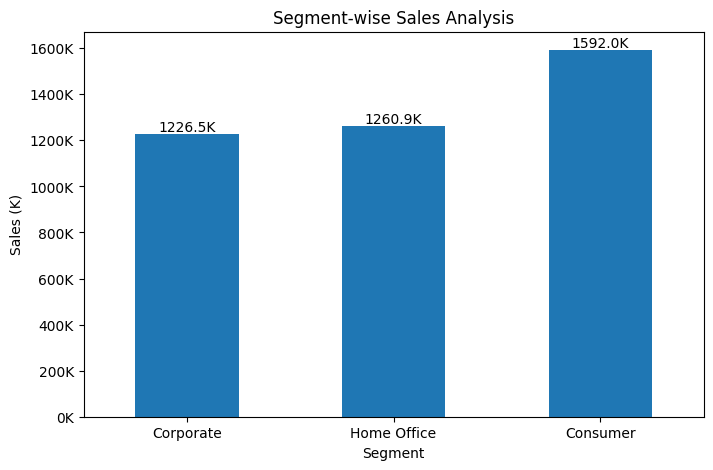

In [58]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = segment_sales.plot(kind='bar')

plt.title('Segment-wise Sales Analysis')
plt.xlabel('Segment')
plt.ylabel('Sales (K)')

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

for i, value in enumerate(segment_sales):
    ax.text(i, value,
            f'{value/1000:.1f}K',
            ha='center',
            va='bottom')

plt.xticks(rotation=0)
plt.show()